# Ford GoBike 2018 Trip Data - Exploratory Data Analysis


# Project Summary -

* This project performs Exploratory Data Analysis (EDA) on Ford GoBike's 2018
trip data, covering all 12 months (January-December) and approximately 1.86 million bike trips across the San Francisco Bay Area. The dataset includes trip duration, start/end station details, timestamps, bike IDs, user type(Subscriber/Customer), and rider demographics (birth year, gender).
* The data was cleaned (handling missing values, duplicates, incorrect data types, and invalid
ages) and enriched with engineered features such as month, day, hour, trip duration in
minutes, age, age group, and weekend/weekday flags. 21 visualizations were created following
the Univariate-Bivariate-Multivariate (UBM) framework to uncover patterns in rider behavior,
usage timing, demographics, and station popularity.
* Key findings show a strong commuter-driven usage pattern dominated by
Subscribers on weekdays, with distinct seasonal and hourly trends, and a smaller but behaviorally distinct casual Customer segment concentrated on weekends and in warmer months. These insights are
translated into actionable business recommendations for improving bike availability, targeted marketing, and revenue diversification.

# Github Link-




# Problem Statement

Ford GoBike, a bike-sharing service operating in the San Francisco Bay Area, generates large volumes of trip-level data every month but lacks a consolidated understanding of how, when, and by whom its bikes are used. Without clear visibility into rider behavior patterns
- such as peak usage hours, seasonal demand shifts, differences between subscribers and
casual riders, and station-level popularity - the business risks inefficient bike
distribution, missed revenue opportunities, and an incomplete picture of its user base.

This project analyzes 12 months of 2018 trip data to identify usage patterns across time, demographics, and location, with the goal of providing data-driven recommendations that help Ford GoBike optimize operations, improve rider experience, and grow both its subscriber and casual rider segments.

# Business Objective

The business objective is to analyze Ford GoBike's 2018 trip data to:

1. Understand rider behavior across user types (Subscriber vs Customer), demographics
   (age, gender), and time (month, day, hour).
2. Identify peak demand periods and high-traffic stations to improve bike availability
   and fleet rebalancing.
3. Uncover differences between Subscriber (commuter) and Customer (casual/leisure) usage
   patterns to inform targeted marketing and pricing strategies.
4. Provide actionable, data-backed recommendations to increase ridership, improve
   operational efficiency, and grow revenue from both existing and untapped user segments.

In [1]:
import pandas as pd            # data manipulation
import numpy as np              # numerical operations
import matplotlib.pyplot as plt # plotting
import seaborn as sns           # statistical visualizations
import glob                     # to fetch multiple file paths
import zipfile                  # to extract zip files
import os                       # file/folder operations
import warnings

warnings.filterwarnings('ignore')  # suppress non-critical warnings for clean output

# Set consistent plot styling for the whole notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# ============================================================
# STEP 2: MOUNT GOOGLE DRIVE
# ============================================================
# This gives the notebook access to files stored in your Drive.
# Requires a one-time authentication click (standard for Colab, not a "manual step" issue).

from google.colab import drive

try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

Mounted at /content/drive
Google Drive mounted successfully.


In [8]:
# ============================================================
# STEP 3: LOCATE AND EXTRACT ZIP FILES
# ============================================================

# Path to the folder in your Drive where the 12 zip files are uploaded
# CHANGE this path to match your actual Drive folder name
zip_folder_path = '/content/drive/MyDrive/fordgobike_data/'

# Folder where CSVs will be extracted to (created fresh each run)
extract_path = '/content/trip_data/'
os.makedirs(extract_path, exist_ok=True)

try:
    zip_files = sorted(glob.glob(zip_folder_path + '*.zip'))

    if len(zip_files) == 0:
        raise FileNotFoundError("No zip files found. Check zip_folder_path.")

    print(f"Found {len(zip_files)} zip files.")

    # Extract each zip file into extract_path
    for zip_file in zip_files:
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

    print("All zip files extracted successfully.")

except FileNotFoundError as fnf_error:
    print(f"File error: {fnf_error}")
except zipfile.BadZipFile as bz_error:
    print(f"Corrupted zip file skipped: {bz_error}")
except Exception as e:
    print(f"Unexpected error during extraction: {e}")

Found 12 zip files.
All zip files extracted successfully.


In [9]:
# ============================================================
# STEP 4: LOAD ALL CSV FILES AND APPEND INTO ONE DATAFRAME
# ============================================================

all_csv_files = sorted(glob.glob(extract_path + '*.csv'))
print(f"Found {len(all_csv_files)} CSV files.")

df_list = []

for file in all_csv_files:
    try:
        temp_df = pd.read_csv(file)
        df_list.append(temp_df)
    except Exception as e:
        # If any single file fails to load, skip it but don't crash the whole run
        print(f"Skipped {file} due to error: {e}")

try:
    df = pd.concat(df_list, ignore_index=True)
    print(f"All files combined successfully. Final shape: {df.shape}")
except ValueError as ve:
    print(f"Error combining files: {ve}")

Found 12 CSV files.
All files combined successfully. Final shape: (1863721, 16)


In [10]:
# ============================================================
# STEP 5: DATA UNDERSTANDING
# ============================================================

print("First 5 rows:")
display(df.head())

print("\nShape of dataset (rows, columns):", df.shape)

print("\nDataset info:")
df.info()

print("\nStatistical summary (numerical columns):")
display(df.describe())

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No



Shape of dataset (rows, columns): (1863721, 16)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   duration_sec             int64  
 1   start_time               object 
 2   end_time                 object 
 3   start_station_id         float64
 4   start_station_name       object 
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_name         object 
 9   end_station_latitude     float64
 10  end_station_longitude    float64
 11  bike_id                  int64  
 12  user_type                object 
 13  member_birth_year        float64
 14  member_gender            object 
 15  bike_share_for_all_trip  object 
dtypes: float64(7), int64(2), object(7)
memory usage: 227.5+ MB

Statistical summary (numerical columns):


,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.863721e+06,1.753003e+06
mean,8.573026e+02,1.196744e+02,3.776678e+01,-1.223492e+02,1.181730e+02,3.776690e+01,-1.223487e+02,2.296851e+03,1.983088e+03
std,2.370379e+03,1.003976e+02,1.057689e-01,1.654634e-01,1.004403e+02,1.056483e-01,1.650597e-01,1.287733e+03,1.044289e+01
min,6.100000e+01,3.000000e+00,3.726331e+01,-1.224737e+02,3.000000e+00,3.726331e+01,-1.224737e+02,1.100000e+01,1.881000e+03
25%,3.500000e+02,3.300000e+01,3.777106e+01,-1.224114e+02,3.000000e+01,3.777106e+01,-1.224094e+02,1.225000e+03,1.978000e+03
50%,5.560000e+02,8.900000e+01,3.778107e+01,-1.223974e+02,8.800000e+01,3.778127e+01,-1.223971e+02,2.338000e+03,1.985000e+03
75%,8.720000e+02,1.860000e+02,3.779625e+01,-1.222865e+02,1.830000e+02,3.779728e+01,-1.222894e+02,3.333000e+03,1.991000e+03
max,8.636600e+04,3.810000e+02,4.551000e+01,-7.357000e+01,3.810000e+02,4.551000e+01,-7.357000e+01,6.234000e+03,2.000000e+03



Column names:
['duration_sec', 'start_time', 'end_time', 'start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type', 'member_birth_year', 'member_gender', 'bike_share_for_all_trip']


In [11]:
# ============================================================
# STEP 6: DATA CLEANING
# ============================================================

# ---- 6.1 Check missing values ----
print("Missing values per column:")
print(df.isnull().sum())

print("\nMissing % per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
duration_sec                    0
start_time                      0
end_time                        0
start_station_id            11771
start_station_name          11771
start_station_latitude          0
start_station_longitude         0
end_station_id              11771
end_station_name            11771
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110718
member_gender              110367
bike_share_for_all_trip         0
dtype: int64

Missing % per column:
duration_sec               0.00
start_time                 0.00
end_time                   0.00
start_station_id           0.63
start_station_name         0.63
start_station_latitude     0.00
start_station_longitude    0.00
end_station_id             0.63
end_station_name           0.63
end_station_latitude       0.00
end_station_longitude      0.00
bike_id                    0.00
user_type

In [12]:
# ---- 6.2 Check and remove duplicate rows ----
try:
    dup_count = df.duplicated().sum()
    print(f"Duplicate rows found: {dup_count}")

    if dup_count > 0:
        df = df.drop_duplicates()
        print("Duplicates removed.")
    else:
        print("No duplicates found, nothing to remove.")
except Exception as e:
    print(f"Error checking duplicates: {e}")

Duplicate rows found: 0
No duplicates found, nothing to remove.


In [13]:
# ---- 6.3 Fix incorrect data types ----
# start_time / end_time are loaded as strings, converting to proper datetime
try:
    df['start_time'] = pd.to_datetime(df['start_time'])
    df['end_time'] = pd.to_datetime(df['end_time'])
    print("start_time and end_time converted to datetime.")
except Exception as e:
    print(f"Error converting datetime columns: {e}")

# Convert categorical text columns to 'category' dtype (saves memory, speeds up plots)
try:
    df['user_type'] = df['user_type'].astype('category')
    df['member_gender'] = df['member_gender'].astype('category')
    df['bike_share_for_all_trip'] = df['bike_share_for_all_trip'].astype('category')
    print("Categorical columns converted successfully.")
except Exception as e:
    print(f"Error converting categorical columns: {e}")

print("\nUpdated dtypes:")
print(df.dtypes)

start_time and end_time converted to datetime.
Categorical columns converted successfully.

Updated dtypes:
duration_sec                        int64
start_time                 datetime64[ns]
end_time                   datetime64[ns]
start_station_id                  float64
start_station_name                 object
start_station_latitude            float64
start_station_longitude           float64
end_station_id                    float64
end_station_name                   object
end_station_latitude              float64
end_station_longitude             float64
bike_id                             int64
user_type                        category
member_birth_year                 float64
member_gender                    category
bike_share_for_all_trip          category
dtype: object


In [14]:
# ---- 6.4 Handle missing values in station id/name ----
# These are a tiny fraction (~0.6%) of the data, safe to drop rather than impute
try:
    before = df.shape[0]
    df = df.dropna(subset=['start_station_id', 'end_station_id'])
    after = df.shape[0]
    print(f"Dropped {before - after} rows with missing station info.")
except Exception as e:
    print(f"Error dropping missing station rows: {e}")

Dropped 11771 rows with missing station info.


In [15]:
# ---- 6.5 Handle missing values in member_gender ----
# ~6% missing — too much to drop, so label as 'Unknown' instead of losing data
try:
    if 'Unknown' not in df['member_gender'].cat.categories:
        df['member_gender'] = df['member_gender'].cat.add_categories(['Unknown'])
    df['member_gender'] = df['member_gender'].fillna('Unknown')
    print("Missing gender values filled with 'Unknown'.")
    print(df['member_gender'].value_counts())
except Exception as e:
    print(f"Error handling gender missing values: {e}")

Missing gender values filled with 'Unknown'.
member_gender
Male       1279545
Female      435361
Unknown     110043
Other        27001
Name: count, dtype: int64


In [16]:
# ---- 6.6 Create age column from birth year ----
try:
    df['age'] = 2018 - df['member_birth_year']
    print("Age column created.")
    print(df['age'].describe())
except Exception as e:
    print(f"Error creating age column: {e}")

Age column created.
count    1.741556e+06
mean     3.493921e+01
std      1.045133e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      1.370000e+02
Name: age, dtype: float64


In [17]:
# ---- 6.7 Remove invalid ages ----
# Ages below 13 or above 80 are unrealistic for bike-share riders (data entry errors)
# NaN ages are kept (missing birth_year rows) so they still contribute to non-age charts
try:
    before = df.shape[0]
    df = df[((df['age'] >= 13) & (df['age'] <= 80)) | (df['age'].isna())]
    after = df.shape[0]
    print(f"Removed {before - after} rows with invalid age values.")
    print(df['age'].describe())
except Exception as e:
    print(f"Error filtering invalid ages: {e}")

Removed 2427 rows with invalid age values.
count    1.739129e+06
mean     3.484818e+01
std      1.015435e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      8.000000e+01
Name: age, dtype: float64


In [18]:
# ---- 6.8 Final sanity check after cleaning ----
print("Final missing values:")
print(df.isnull().sum())

print("\nFinal shape after cleaning:", df.shape)
df.info()

Final missing values:
duration_sec                    0
start_time                      0
end_time                        0
start_station_id                0
start_station_name              0
start_station_latitude          0
start_station_longitude         0
end_station_id                  0
end_station_name                0
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110394
member_gender                   0
bike_share_for_all_trip         0
age                        110394
dtype: int64

Final shape after cleaning: (1849523, 17)
<class 'pandas.core.frame.DataFrame'>
Index: 1849523 entries, 0 to 1863720
Data columns (total 17 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duration_sec             int64         
 1   start_time               datetime64[ns]
 2   end_time                 datetime64[ns]
 3   start_

In [19]:
# ============================================================
# STEP 7: FEATURE ENGINEERING
# ============================================================

# ---- 7.1 Extract month, day, hour from start_time ----
try:
    df['month'] = df['start_time'].dt.month_name()
    df['day'] = df['start_time'].dt.day_name()
    df['hour'] = df['start_time'].dt.hour
    print("Month, day, and hour extracted successfully.")
    display(df[['start_time', 'month', 'day', 'hour']].head())
except Exception as e:
    print(f"Error extracting date parts: {e}")

Month, day, and hour extracted successfully.


,start_time,month,day,hour
0,2018-01-31 22:52:35.239,January,Wednesday,22
1,2018-01-31 16:13:34.351,January,Wednesday,16
2,2018-01-31 14:23:55.889,January,Wednesday,14
3,2018-01-31 14:53:23.562,January,Wednesday,14
4,2018-01-31 19:52:24.667,January,Wednesday,19


In [20]:
# ---- 7.2 Trip duration in minutes ----
# duration_sec is in seconds; minutes is more readable for chart axes
try:
    df['trip_minutes'] = round(df['duration_sec'] / 60, 2)
    print("Trip duration in minutes created.")
    display(df[['duration_sec', 'trip_minutes']].head())
except Exception as e:
    print(f"Error creating trip_minutes: {e}")

Trip duration in minutes created.


,duration_sec,trip_minutes
0,75284,1254.73
1,85422,1423.70
2,71576,1192.93
3,61076,1017.93
4,39966,666.10


In [21]:
# ---- 7.3 Weekend flag ----
try:
    df['is_weekend'] = df['day'].isin(['Saturday', 'Sunday']).map({True: 'Weekend', False: 'Weekday'})
    print("Weekend flag created.")
    print(df['is_weekend'].value_counts())
except Exception as e:
    print(f"Error creating weekend flag: {e}")

Weekend flag created.
is_weekend
Weekday    1523893
Weekend     325630
Name: count, dtype: int64


In [22]:
# ---- 7.4 Order month and day as categorical (so charts display Jan->Dec, Mon->Sun) ----
try:
    month_order = ['January','February','March','April','May','June',
                   'July','August','September','October','November','December']
    day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

    df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
    df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)
    print("Month and day set as ordered categories.")
except Exception as e:
    print(f"Error ordering categories: {e}")

Month and day set as ordered categories.


In [23]:
# ---- 7.5 Age bins (useful for some categorical charts later) ----
try:
    bins = [0, 18, 25, 35, 45, 55, 65, 100]
    labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
    print("Age groups created.")
    print(df['age_group'].value_counts())
except Exception as e:
    print(f"Error creating age groups: {e}")

Age groups created.
age_group
26-35    789490
36-45    389122
18-25    284441
46-55    185256
56-65     71540
65+       13991
<18        5289
Name: count, dtype: int64


In [24]:
# ---- 7.6 Final check on engineered features ----
try:
    display(df[['start_time','month','day','hour','trip_minutes','age','age_group','is_weekend','user_type','member_gender']].head())
    print("\nFinal shape after feature engineering:", df.shape)
    df.info()
except Exception as e:
    print(f"Error displaying final dataframe: {e}")

,start_time,month,day,hour,trip_minutes,age,age_group,is_weekend,user_type,member_gender
0,2018-01-31 22:52:35.239,January,Wednesday,22,1254.73,32.0,26-35,Weekday,Subscriber,Male
1,2018-01-31 16:13:34.351,January,Wednesday,16,1423.70,NaN,NaN,Weekday,Customer,Unknown
2,2018-01-31 14:23:55.889,January,Wednesday,14,1192.93,22.0,18-25,Weekday,Customer,Male
3,2018-01-31 14:53:23.562,January,Wednesday,14,1017.93,NaN,NaN,Weekday,Customer,Unknown
4,2018-01-31 19:52:24.667,January,Wednesday,19,666.10,27.0,26-35,Weekday,Subscriber,Male



Final shape after feature engineering: (1849523, 23)
<class 'pandas.core.frame.DataFrame'>
Index: 1849523 entries, 0 to 1863720
Data columns (total 23 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duration_sec             int64         
 1   start_time               datetime64[ns]
 2   end_time                 datetime64[ns]
 3   start_station_id         float64       
 4   start_station_name       object        
 5   start_station_latitude   float64       
 6   start_station_longitude  float64       
 7   end_station_id           float64       
 8   end_station_name         object        
 9   end_station_latitude     float64       
 10  end_station_longitude    float64       
 11  bike_id                  int64         
 12  user_type                category      
 13  member_birth_year        float64       
 14  member_gender            category      
 15  bike_share_for_all_trip  category      
 16  age                    

In [25]:
# ============================================================
# SECTION 2: UNDERSTANDING YOUR VARIABLES
# ============================================================

# ---- 2.1 Dataset Columns ----
try:
    print("Dataset Columns:")
    print(df.columns.tolist())
except Exception as e:
    print(f"Error listing columns: {e}")

Dataset Columns:
['duration_sec', 'start_time', 'end_time', 'start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type', 'member_birth_year', 'member_gender', 'bike_share_for_all_trip', 'age', 'month', 'day', 'hour', 'trip_minutes', 'is_weekend', 'age_group']


In [26]:
# ---- 2.2 Dataset Describe ----
try:
    print("Statistical summary (numerical columns):")
    display(df.describe())

    print("\nStatistical summary (categorical columns):")
    display(df.describe(include='category'))
except Exception as e:
    print(f"Error generating describe: {e}")

Statistical summary (numerical columns):


,duration_sec,start_time,end_time,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year,age,hour,trip_minutes
count,1.849523e+06,1849523,1849523,1.849523e+06,1.849523e+06,1.849523e+06,1.849523e+06,1.849523e+06,1.849523e+06,1.849523e+06,1.739129e+06,1.739129e+06,1.849523e+06,1.849523e+06
mean,8.531300e+02,2018-07-14 14:33:01.823016704,2018-07-14 14:47:15.446704128,1.196891e+02,3.776901e+01,-1.223520e+02,1.181939e+02,3.776913e+01,-1.223515e+02,2.284969e+03,1.983152e+03,3.484818e+01,1.350707e+01,1.421883e+01
min,6.100000e+01,2018-01-01 00:01:53.847000,2018-01-01 00:10:06.241000,3.000000e+00,3.726331e+01,-1.224737e+02,3.000000e+00,3.726331e+01,-1.224737e+02,1.100000e+01,1.938000e+03,1.800000e+01,0.000000e+00,1.020000e+00
25%,3.500000e+02,2018-05-03 19:51:59.046000128,2018-05-03 20:03:26.586500096,3.300000e+01,3.777106e+01,-1.224116e+02,3.000000e+01,3.777143e+01,-1.224099e+02,1.216000e+03,1.978000e+03,2.700000e+01,9.000000e+00,5.830000e+00
50%,5.550000e+02,2018-07-18 16:49:52.400999936,2018-07-18 17:03:02.492000,8.900000e+01,3.778107e+01,-1.223974e+02,8.800000e+01,3.778127e+01,-1.223971e+02,2.327000e+03,1.985000e+03,3.300000e+01,1.400000e+01,9.250000e+00
75%,8.700000e+02,2018-10-01 09:12:49.798000128,2018-10-01 09:23:23.263500032,1.860000e+02,3.779728e+01,-1.222894e+02,1.830000e+02,3.779728e+01,-1.222914e+02,3.312000e+03,1.991000e+03,4.000000e+01,1.700000e+01,1.450000e+01
max,8.636600e+04,2018-12-31 23:59:12.097000,2019-01-01 15:05:21.558000,3.810000e+02,3.788022e+01,-1.218333e+02,3.810000e+02,3.788022e+01,-1.218333e+02,6.234000e+03,2.000000e+03,8.000000e+01,2.300000e+01,1.439430e+03
std,2.340142e+03,NaN,NaN,1.004043e+02,1.008252e-01,1.186641e-01,1.004470e+02,1.006834e-01,1.181027e-01,1.283072e+03,1.015435e+01,1.015435e+01,4.742738e+00,3.900238e+01



Statistical summary (categorical columns):


,user_type,member_gender,bike_share_for_all_trip,month,day,age_group
count,1849523,1849523,1849523,1849523,1849523,1739129
unique,2,4,2,12,7,7
top,Subscriber,Male,No,October,Tuesday,26-35
freq,1572717,1277930,1689187,199939,317051,789490


In [27]:
# ---- 2.3 Check unique values for each variable ----
try:
    for col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")
except Exception as e:
    print(f"Error checking unique values: {e}")

duration_sec: 16570 unique values
start_time: 1849388 unique values
end_time: 1849414 unique values
start_station_id: 331 unique values
start_station_name: 348 unique values
start_station_latitude: 351 unique values
start_station_longitude: 351 unique values
end_station_id: 331 unique values
end_station_name: 348 unique values
end_station_latitude: 351 unique values
end_station_longitude: 351 unique values
bike_id: 4853 unique values
user_type: 2 unique values
member_birth_year: 63 unique values
member_gender: 4 unique values
bike_share_for_all_trip: 2 unique values
age: 63 unique values
month: 12 unique values
day: 7 unique values
hour: 24 unique values
trip_minutes: 16570 unique values
is_weekend: 2 unique values
age_group: 7 unique values


In [28]:
# ---- 2.4 Deep dive into key categorical variable values ----
try:
    print("User Type values:\n", df['user_type'].value_counts(), "\n")
    print("Gender values:\n", df['member_gender'].value_counts(), "\n")
    print("Bike Share For All Trip values:\n", df['bike_share_for_all_trip'].value_counts(), "\n")
    print("Age Group values:\n", df['age_group'].value_counts(), "\n")
except Exception as e:
    print(f"Error displaying value counts: {e}")

User Type values:
 user_type
Subscriber    1572717
Customer       276806
Name: count, dtype: int64 

Gender values:
 member_gender
Male       1277930
Female      434917
Unknown     110043
Other        26633
Name: count, dtype: int64 

Bike Share For All Trip values:
 bike_share_for_all_trip
No     1689187
Yes     160336
Name: count, dtype: int64 

Age Group values:
 age_group
26-35    789490
36-45    389122
18-25    284441
46-55    185256
56-65     71540
65+       13991
<18        5289
Name: count, dtype: int64 



In [29]:
# ============================================================
# SECTION 3: DATA WRANGLING CODE
# (Summary — references cleaning & feature engineering already performed above)
# ============================================================
print("Data wrangling steps already applied:")
print("1. Removed duplicate rows")
print("2. Converted start_time/end_time to datetime")
print("3. Converted user_type, member_gender, bike_share_for_all_trip to category dtype")
print("4. Dropped rows with missing station id/name (~0.6% of data)")
print("5. Filled missing gender values with 'Unknown'")
print("6. Created age column from member_birth_year, removed invalid ages (<13 or >80)")
print("7. Engineered month, day, hour, trip_minutes, is_weekend, age_group")
print(f"\nFinal cleaned dataset shape: {df.shape}")

Data wrangling steps already applied:
1. Removed duplicate rows
2. Converted start_time/end_time to datetime
3. Converted user_type, member_gender, bike_share_for_all_trip to category dtype
4. Dropped rows with missing station id/name (~0.6% of data)
5. Filled missing gender values with 'Unknown'
6. Created age column from member_birth_year, removed invalid ages (<13 or >80)
7. Engineered month, day, hour, trip_minutes, is_weekend, age_group

Final cleaned dataset shape: (1849523, 23)


**I combined 12 months of 2018 Ford GoBike trip data (~1.86M rows) into a
single dataset.

Rows missing station info (0.6percent) were dropped as negligible.

Missing gender (6percent) was
labeled 'Unknown' rather than dropped, to preserve data volume for non-gender analysis.

Invalid ages (from birth years like 1881) were filtered to a realistic 13-80 range.

I engineered time-based features (month, day, hour, weekend flag) and duration-based features (trip_minutes, age, age_group) to enable time-pattern and demographic analysis
in the visualization section**.

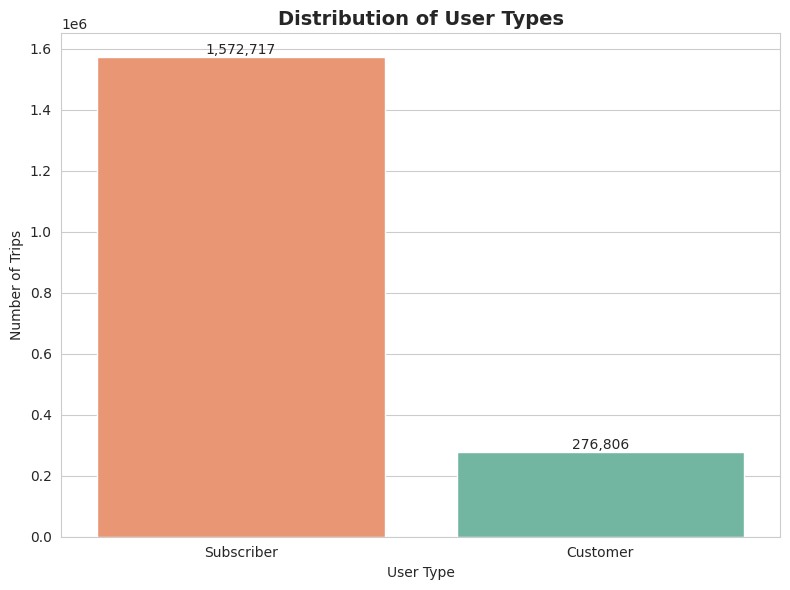

In [30]:

try:
    plt.figure(figsize=(8,6))
    ax = sns.countplot(data=df, x='user_type', hue='user_type', palette='Set2', legend=False, order=df['user_type'].value_counts().index)
    plt.title('Distribution of User Types', fontsize=14, fontweight='bold')
    plt.xlabel('User Type')
    plt.ylabel('Number of Trips')

    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A count plot is the standard way to visualize the frequency distribution of a single categorical variable. Since user_type has only two categories (Subscriber, Customer), a bar chart makes the volume difference immediately clear and easy to compare.

# 2. What are the insights found from the chart?

The vast majority of trips are made by Subscribers rather than Customers. Subscribers are members who pay for recurring access (commuters), while Customers are one-time/casual riders (often tourists or occasional users). This shows the service is primarily used for routine daily transportation rather than casual/tourist use.

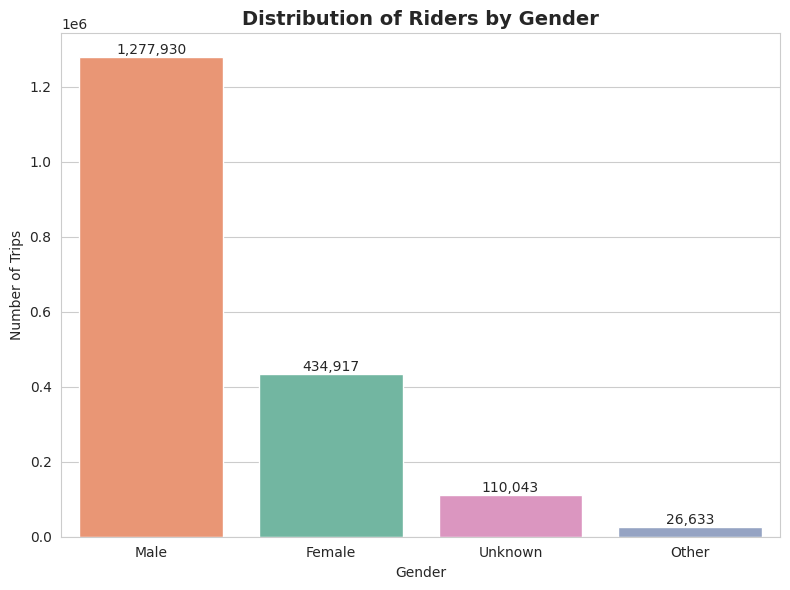

In [31]:

try:
    plt.figure(figsize=(8,6))
    ax = sns.countplot(data=df, x='member_gender', hue='member_gender', palette='Set2',
                        legend=False, order=df['member_gender'].value_counts().index)
    plt.title('Distribution of Riders by Gender', fontsize=14, fontweight='bold')
    plt.xlabel('Gender')
    plt.ylabel('Number of Trips')

    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

Gender is a categorical variable with a small number of distinct values, so a count plot is the clearest way to compare the volume of riders across each gender category, including the 'Unknown' group we created during cleaning.

# 2. What are the insights found from the chart?

Male riders make up the largest share of trips by a significant margin, followed by Female, then a smaller Other category. The 'Unknown' group (originally missing values) also holds a noticeable share, reminding us that gender data collection is incomplete for a real portion
of riders.

# 3. Will the gained insights help creating a positive business impact?

Understanding the gender skew helps tailor marketing, bike design, and safety features (e.g., lighting, station placement) toward the dominant user base while identifying underrepresented groups to target for growth.


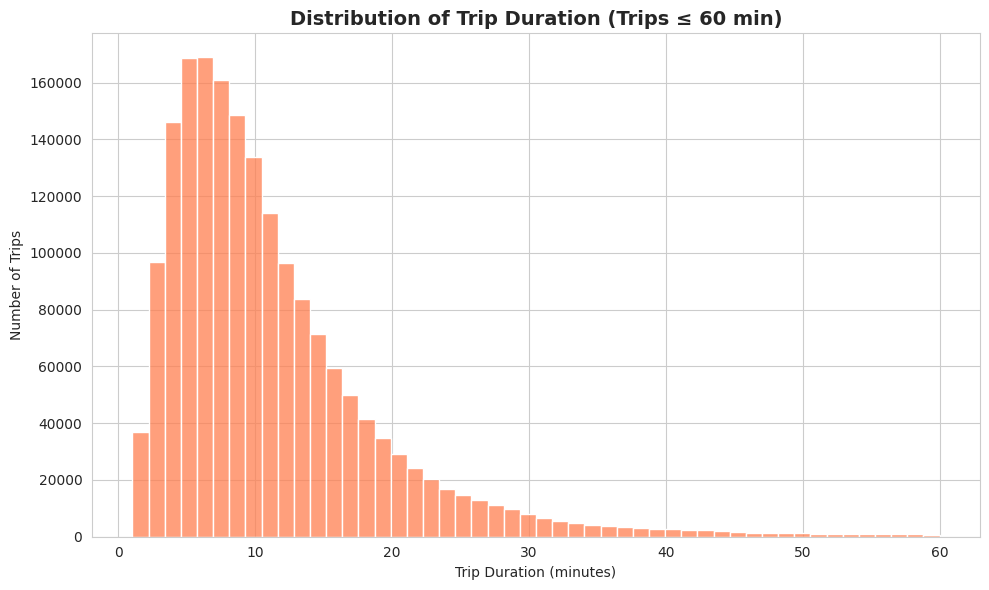

In [32]:

try:
    # Filter extreme outliers for a readable plot (trips over 60 mins are rare/likely anomalies)
    plot_data = df[df['trip_minutes'] <= 60]

    plt.figure(figsize=(10,6))
    sns.histplot(plot_data['trip_minutes'], bins=50, color='coral')
    plt.title('Distribution of Trip Duration (Trips ≤ 60 min)', fontsize=14, fontweight='bold')
    plt.xlabel('Trip Duration (minutes)')
    plt.ylabel('Number of Trips')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

Trip duration is continuous and heavily right-skewed with extreme outliers (some trips last hours/days), so a histogram capped at a reasonable range (60 min) gives a clearer picture of typical usage than including outliers.

# 2. What are the insights found from the chart?

Most trips last between 5-15 minutes, consistent with short commute or last-mile travel rather than leisure rides. Very few trips exceed 30 minutes.

# 3. Business impact

 Short average trip times support a pricing model built around quick point-to-point trips (e.g., first 30-45 min free/included in membership) rather than long-duration pricing.
Risk: Long-tail extreme-duration trips (bikes checked out for hours/days) likely represent lost/stolen/forgotten bikes — a cost center worth investigating and addressing with reminder notifications or late fees.

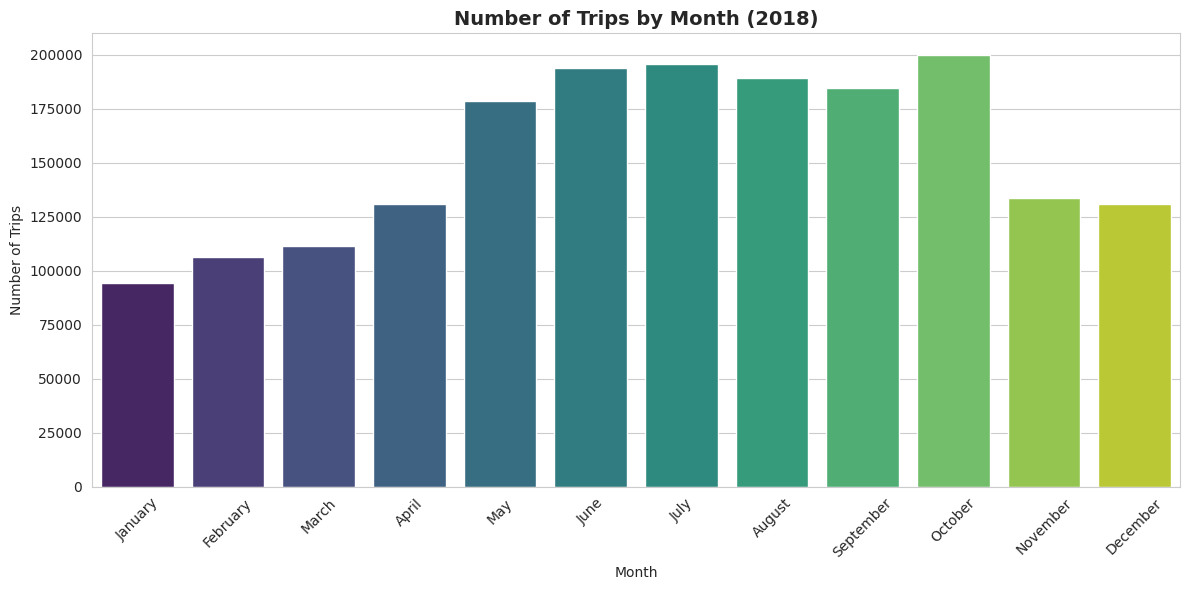

In [36]:

try:
    plt.figure(figsize=(12,6))
    ax = sns.countplot(data=df, x='month', hue='month', palette='viridis', legend=False)
    plt.title('Number of Trips by Month (2018)', fontsize=14, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Number of Trips')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A count plot ordered chronologically (Jan-Dec, set earlier as ordered categorical) is the clearest way to reveal seasonal trends across the year.

# 2. What are the insights found from the chart?

Ridership trends upward through spring and summer, peaking around mid-to-late year, then
tapers off toward winter months. This points to a strong seasonal/weather effect on usage.

# 3. Business impact?

Positive: Enables demand forecasting — the business can pre-position more bikes and staff during high season and run winter-specific promotions/discounts to offset the seasonal dip.
Risk: Heavy reliance on warm-weather months means revenue is seasonal; the business should plan cash flow and bike maintenance schedules (winter = good time for fleet servicing) around this cycle

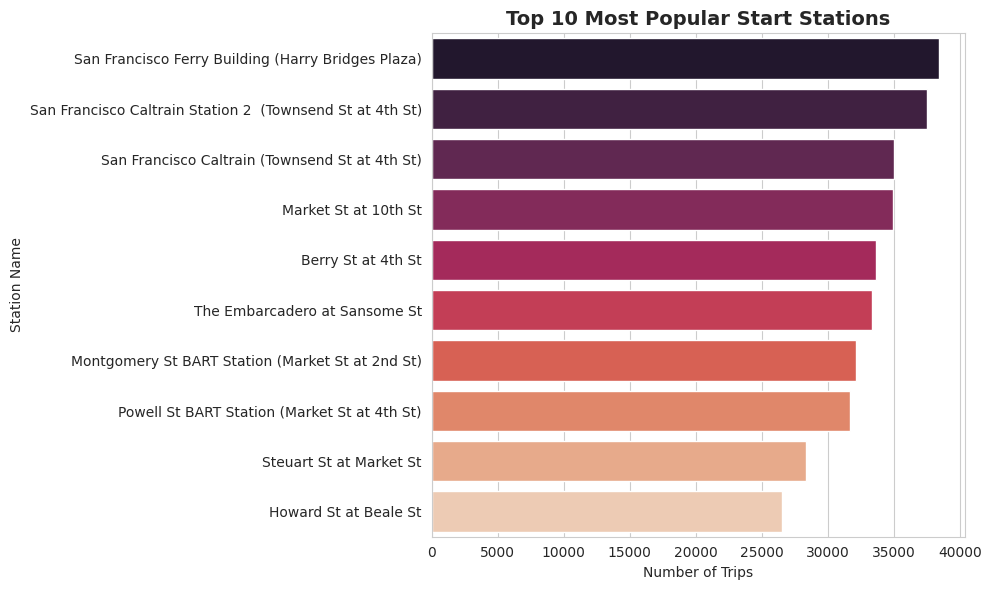

In [37]:

try:
    top_stations = df['start_station_name'].value_counts().head(10)

    plt.figure(figsize=(10,6))
    sns.barplot(x=top_stations.values, y=top_stations.index, hue=top_stations.index, palette='rocket', legend=False)
    plt.title('Top 10 Most Popular Start Stations', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Trips')
    plt.ylabel('Station Name')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for ranking categorical items (stations) by frequency, and horizontal orientation keeps long station names readable.

# 2. What are the insights found from the chart?

A small number of stations — mostly near transit hubs (e.g., Caltrain, Ferry Building) — account for a disproportionately large share of trips compared to the rest of the network.

# 3. Business impact?

Positive: These high-traffic stations should be prioritized for maintenance, dock capacity expansion, and bike availability monitoring since they drive the most usage/revenue.
Risk: Over-concentration creates a single point of failure — if a top station goes out of service (maintenance, event closure), it disproportionately disrupts overall ridership. The business should have contingency/rebalancing plans for these key stations.

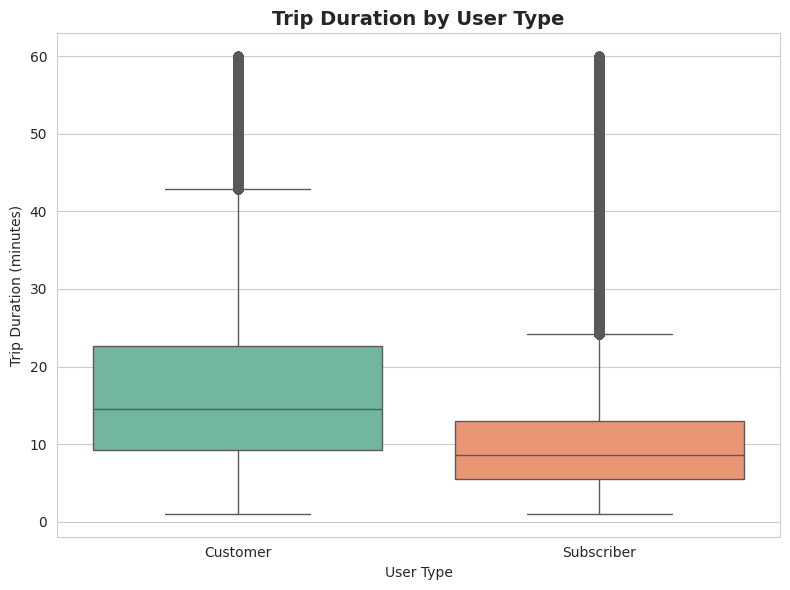

In [38]:
try:
    plot_data = df[df['trip_minutes'] <= 60]

    plt.figure(figsize=(8,6))
    sns.boxplot(data=plot_data, x='user_type', y='trip_minutes', hue='user_type', palette='Set2', legend=False)
    plt.title('Trip Duration by User Type', fontsize=14, fontweight='bold')
    plt.xlabel('User Type')
    plt.ylabel('Trip Duration (minutes)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A box plot is the standard way to compare the distribution (median, spread, outliers) of a numerical variable across categories — ideal for numerical-categorical bivariate analysis.

# 2. What are the insights found from the chart?

Customers (casual riders) take noticeably longer trips on average than Subscribers, who tend to have short, consistent trip durations — consistent with Subscribers using bikes for quick commutes and Customers using them more for leisure/exploration.

# 3. Business impact?
Positive: Since Customers take longer trips, per-minute or tiered pricing (rather than flat fee) could capture more revenue from casual riders without discouraging Subscriber commute usage.
Risk: If Customer trips regularly approach time-based fee thresholds, it may create unexpected charges and dissatisfaction — clear in-app duration warnings could reduce complaints and improve retention

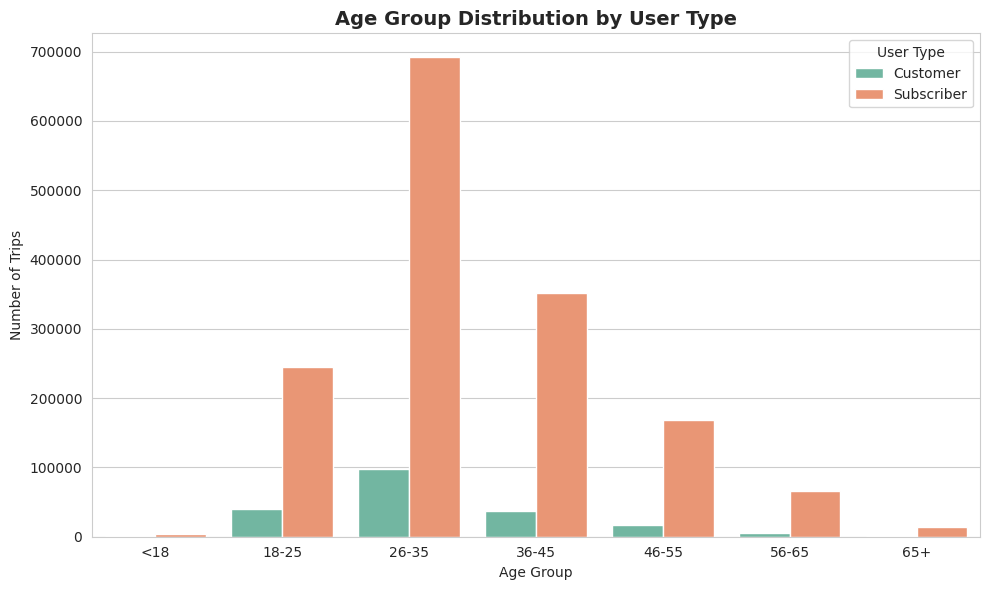

In [40]:

try:
    plt.figure(figsize=(10,6))
    sns.countplot(data=df, x='age_group', hue='user_type', palette='Set2')
    plt.title('Age Group Distribution by User Type', fontsize=14, fontweight='bold')
    plt.xlabel('Age Group')
    plt.ylabel('Number of Trips')
    plt.legend(title='User Type')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A grouped count plot is the standard way to compare two categorical variables together, showing how user_type composition changes across age groups.

# 2. What are the insights found from the chart?

Subscribers dominate across every age group, but the gap between Subscriber and Customer counts is narrower in the youngest and oldest age brackets — suggesting casual usage is relatively more common among very young and older riders.

# 3. Business impact?

Positive: The 26-45 age range is clearly the strongest Subscriber base — retention programs and loyalty perks should be concentrated here.
Risk: Younger and older riders leaning more casual suggests untapped subscription potential — targeted trial memberships for these age brackets could convert more Customers to Subscribers.

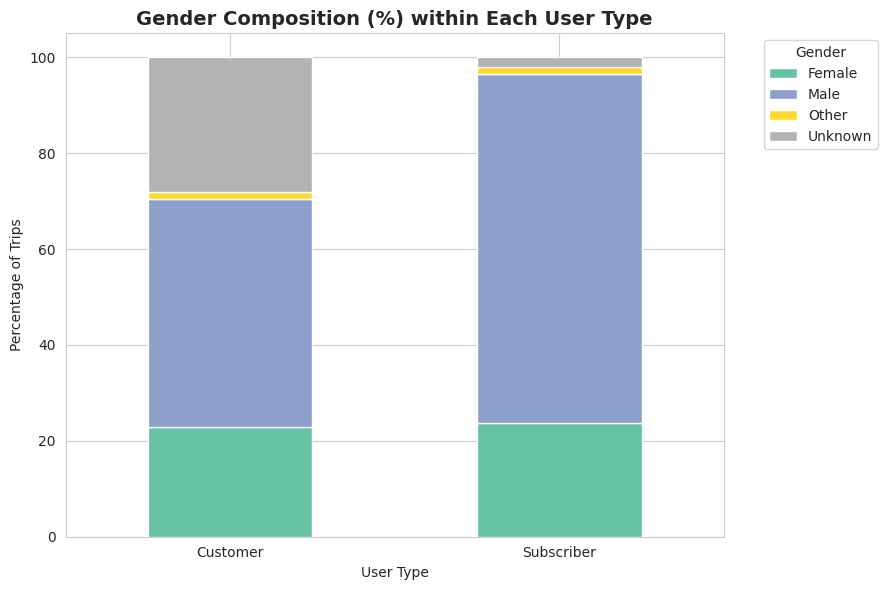

In [41]:

try:
    gender_usertype = pd.crosstab(df['user_type'], df['member_gender'], normalize='index') * 100

    gender_usertype.plot(kind='bar', stacked=True, figsize=(9,6), colormap='Set2')
    plt.title('Gender Composition (%) within Each User Type', fontsize=14, fontweight='bold')
    plt.xlabel('User Type')
    plt.ylabel('Percentage of Trips')
    plt.legend(title='Gender', bbox_to_anchor=(1.05,1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A normalized stacked bar chart shows proportional composition rather than raw counts, making it easy to compare gender mix between user types regardless of their different overall trip volumes.

# 2. What are the insights found from the chart?
The proportion of male riders is high in both groups, but Customers show a slightly higher share of Female and Unknown-gender riders compared to Subscribers — suggesting the casual segment is marginally more gender-diverse.

# 3. Business impact?

Positive: If growing female ridership is a business goal, the Customer segment is closer to that target and may respond better to conversion campaigns encouraging casual female riders to subscribe.
Risk: The consistently low female share in Subscribers signals a retention/appeal gap for committed membership among women — worth researching directly (safety perception, bike design, route lighting)

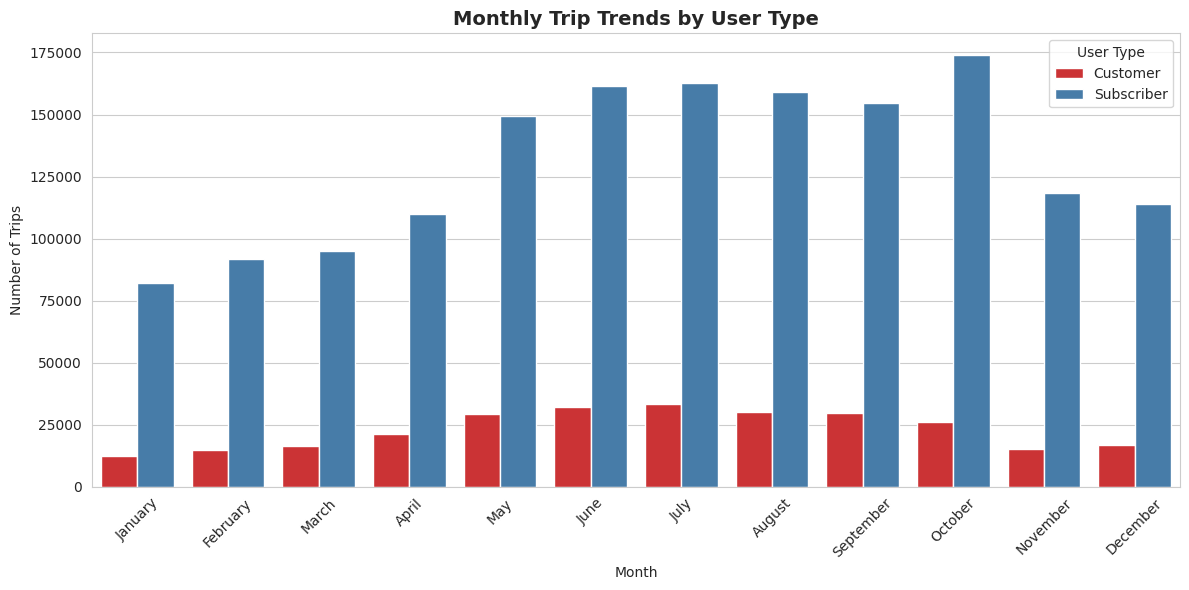

In [42]:

try:
    plt.figure(figsize=(12,6))
    sns.countplot(data=df, x='month', hue='user_type', palette='Set1')
    plt.title('Monthly Trip Trends by User Type', fontsize=14, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Number of Trips')
    plt.xticks(rotation=45)
    plt.legend(title='User Type')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

Splitting the monthly trend (from Chart 5) by user_type reveals whether seasonality affects Subscribers and Customers equally or differently.

# 2. What are the insights found from the chart?

Customer trips show a much sharper seasonal swing — rising steeply in summer and dropping in winter — while Subscriber trips stay comparatively stable year-round, dipping only slightly in colder months.

# 3. Business impact?

Positive: Confirms Subscribers provide a stable revenue base year-round, which is valuable for predictable planning; summer marketing budget should be weighted toward acquiring Customers (tourists/casual riders) since that's when they're most active.
Risk: Customer revenue is highly seasonal and unreliable in winter — the business shouldn't
over-invest in casual-rider-focused infrastructure that sits underused for months.

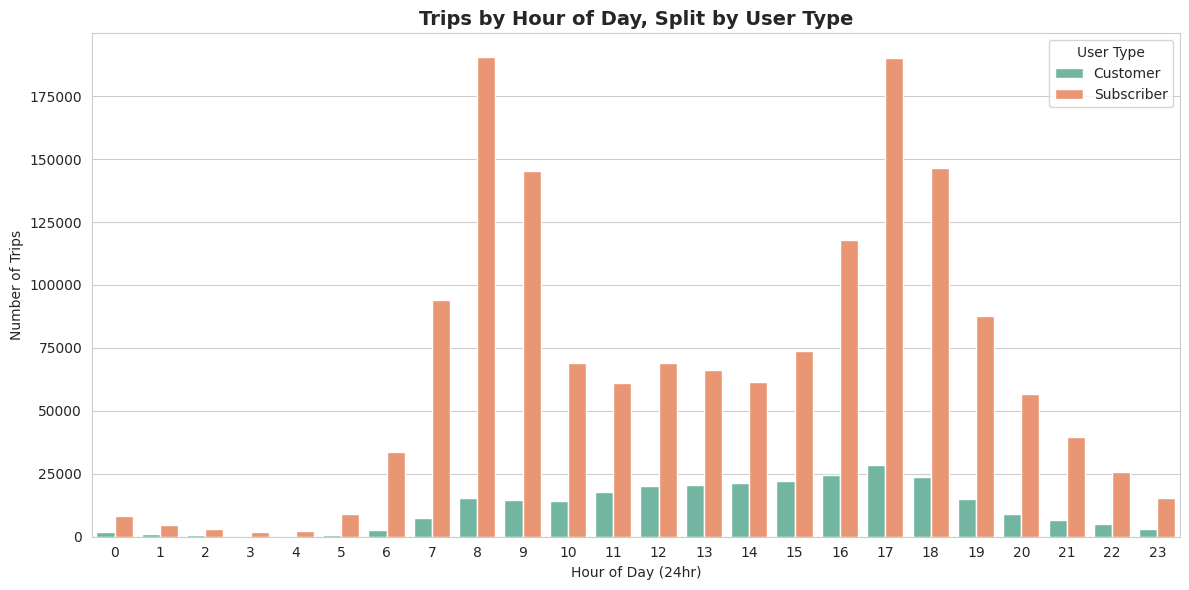

In [51]:

try:
    plt.figure(figsize=(12,6))
    sns.countplot(data=df, x='hour', hue='user_type', palette='Set2')
    plt.title('Trips by Hour of Day, Split by User Type', fontsize=14, fontweight='bold')
    plt.xlabel('Hour of Day (24hr)')
    plt.ylabel('Number of Trips')
    plt.legend(title='User Type')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

Overlaying user_type on the hourly count plot reveals whether the commute-hour peaks
identified in Chart 6 are driven by a specific user segment.

# 2. What is/are the insight(s) found from the chart?

The 8-9 AM and 5-6 PM peaks are almost entirely driven by Subscribers, confirming they are
commuters. Customer trips are spread more evenly across daytime hours without sharp peaks.

# 3. Business impact?

Positive: Confirms bike rebalancing/staffing investment during rush hours should prioritize
Subscriber-heavy commuter routes/stations.
Risk: If Subscriber commute demand isn't met during peaks (bike shortages), it directly
risks losing the most loyal, highest-value user segment — this is the highest-priority
operational risk in the data.

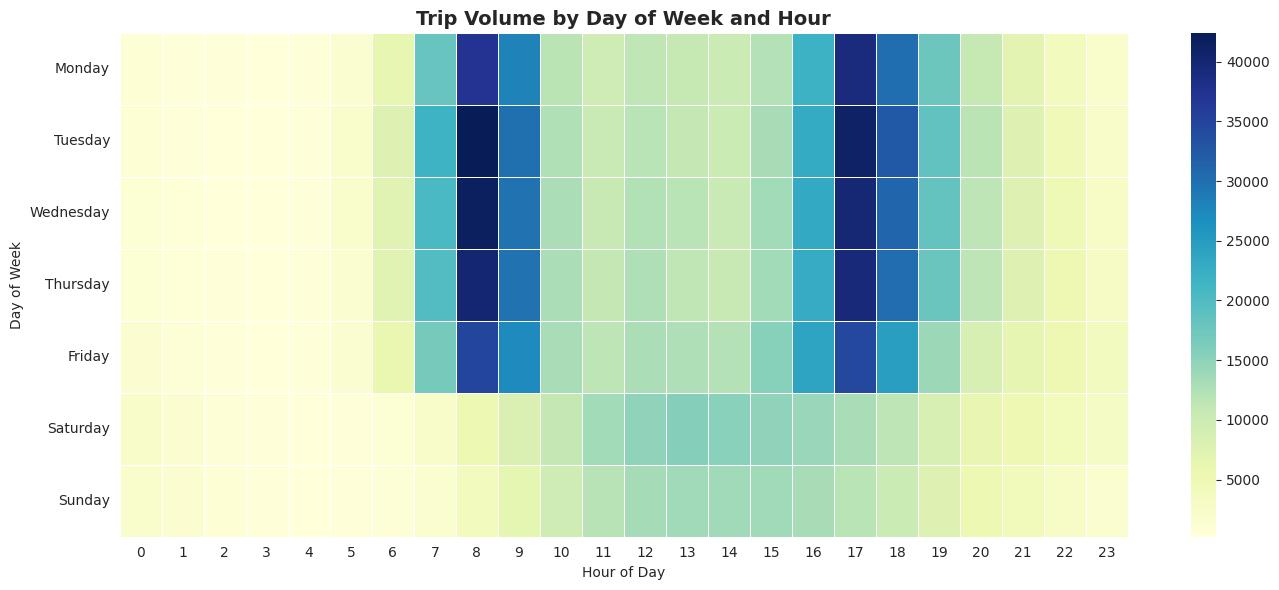

In [43]:

try:
    heatmap_data = df.groupby(['day', 'hour'], observed=True).size().unstack()

    plt.figure(figsize=(14,6))
    sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.5)
    plt.title('Trip Volume by Day of Week and Hour', fontsize=14, fontweight='bold')
    plt.xlabel('Hour of Day')
    plt.ylabel('Day of Week')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A heatmap is ideal for visualizing the interaction between two categorical/time dimensions (day and hour) with a third numerical value (trip count) shown through color intensity — a true multivariate view.

# 2. What is/are the insight(s) found from the chart?

Weekdays show sharp, dark bands at 8-9 AM and 5-6 PM (commute peaks), while weekends show a flatter, more spread-out pattern peaking gently in the early-to-mid afternoon — confirming two distinct usage rhythms depending on day type.

# 3. Business impact?

Positive: This precise time x day pattern allows highly targeted fleet rebalancing — e.g., schedule extra bike availability only for weekday rush windows, and shift to afternoon availability on weekends, optimizing operational costs.
Risk: Rebalancing based on average patterns may fail during atypical days (holidays, events); the business should build in flexibility for exceptions

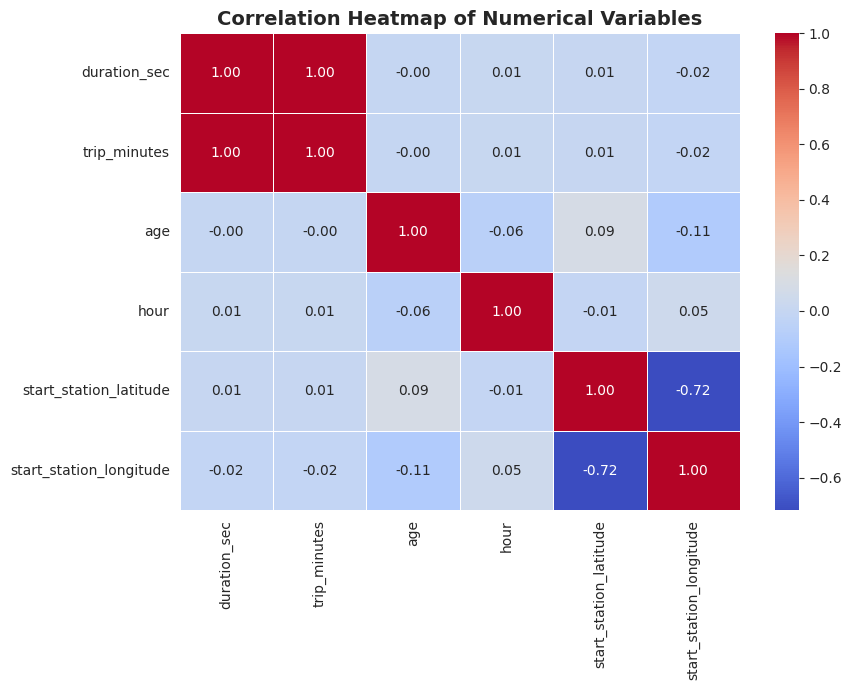

In [44]:

try:
    numeric_cols = ['duration_sec', 'trip_minutes', 'age', 'hour',
                     'start_station_latitude', 'start_station_longitude']
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(9,7))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap of Numerical Variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to quickly scan relationships between all numerical variables simultaneously, highlighting which pairs are strongly or weakly related.

# 2. What are the insights found from the chart?

duration_sec and trip_minutes are perfectly correlated (expected, since one is derived from the other). Age, hour, and station coordinates show very weak correlation with trip duration — confirming that duration is driven by factors outside simple demographics or location coordinates (more likely by trip purpose/user_type, as seen in earlier charts).

# 3. Business impact?

Positive: Confirms that trip duration cannot be reliably predicted from age or location alone, so business strategies (pricing, marketing) should focus on user_type and time-based patterns instead, which showed much stronger relationships in earlier charts.
Risk: None directly — this chart mainly validates and focuses where deeper analysis should go, rather than revealing a standalone risk.

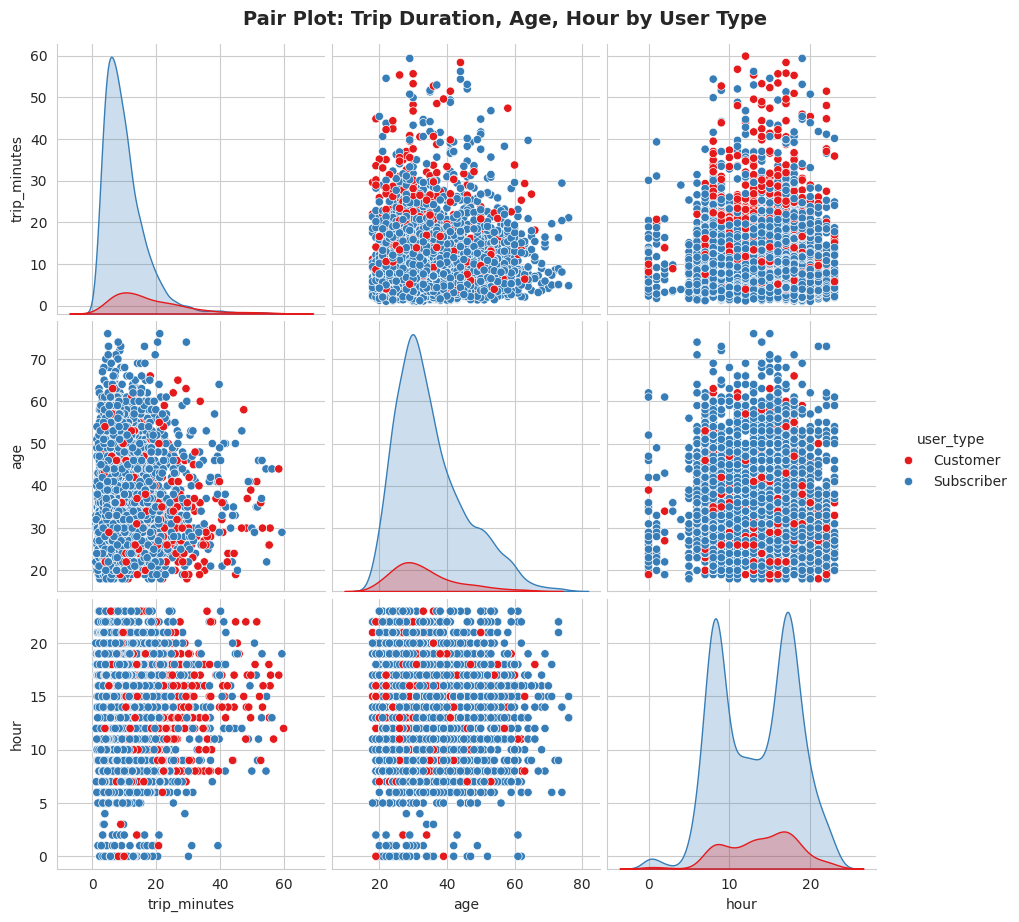

In [45]:

try:
    plot_data = df[df['trip_minutes'] <= 60].sample(5000, random_state=42)

    sns.pairplot(plot_data, vars=['trip_minutes', 'age', 'hour'],
                 hue='user_type', palette='Set1', diag_kind='kde', height=3)
    plt.suptitle('Pair Plot: Trip Duration, Age, Hour by User Type', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A pair plot gives a compact overview of pairwise relationships between multiple numerical variables at once, split by user_type, tying together several earlier individual observations (duration, age, hour) into one consolidated multivariate view.

# 2. What are the insights found from the chart?

The pair plot confirms earlier findings visually: Subscriber points cluster tightly around short durations and commute hours, while Customer points are more spread out across duration and hour, with no strong clustering by age for either group.

# 3. Business impact?

Positive: This consolidated view reinforces that user_type (Subscriber vs Customer) is the single most useful variable for segmenting behavior — it should be the primary lens for future business decisions (pricing, marketing, operations) over age or raw time alone.
Risk: None new — this is a confirmatory/summary chart rather than a new risk finding.

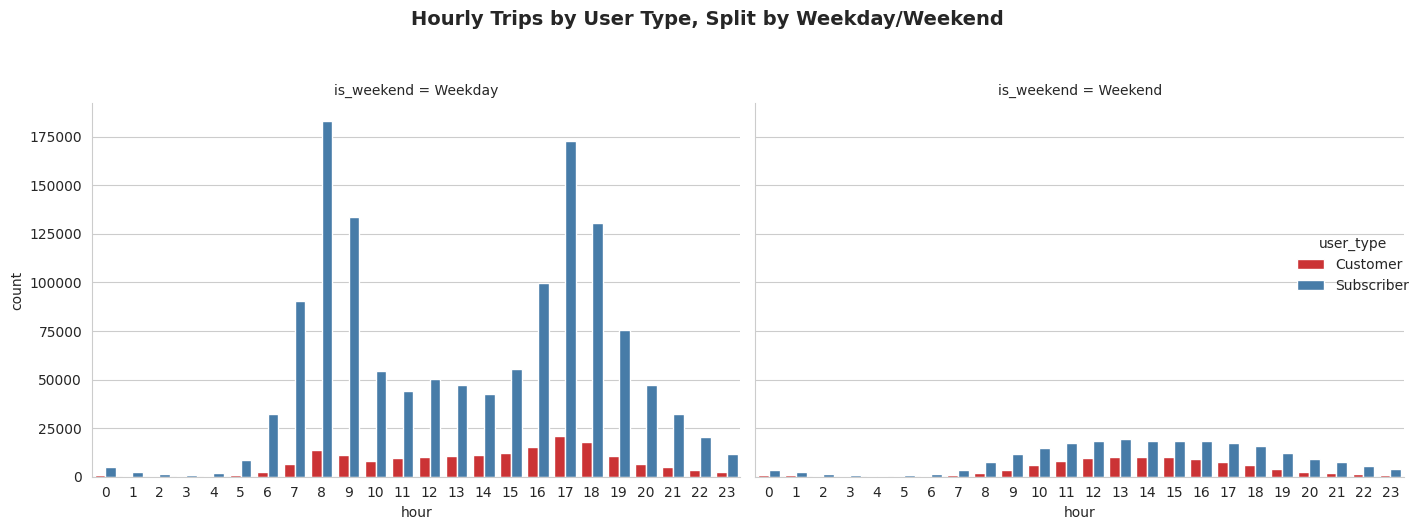

In [47]:

try:
    g = sns.catplot(data=df, x='hour', hue='user_type', col='is_weekend',
                     kind='count', palette='Set1', height=5, aspect=1.3)
    g.fig.suptitle('Hourly Trips by User Type, Split by Weekday/Weekend', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A faceted count plot (one panel per weekend/weekday) with hour on the x-axis and user_type as color lets us compare three variables together without cluttering a single chart.

# 2. What is/are the insight(s) found from the chart?

On weekdays, Subscriber trips show the sharp double-peak commute pattern; on weekends, that peak disappears entirely for Subscribers too, and both user types show a similar, flatter midday-leaning pattern — meaning even Subscribers behave more like casual riders on weekends.

# 3. Business impact?

Positive: Since even Subscribers shift to leisure-style riding on weekends, the business could market weekend-specific perks or route recommendations to Subscribers, deepening engagement beyond pure commuting and improving perceived membership value.
Risk: If fleet rebalancing logic is hardcoded only around weekday commute peaks, weekend demand patterns (flatter, more spread out) could be poorly served — separate weekend rebalancing logic is needed.

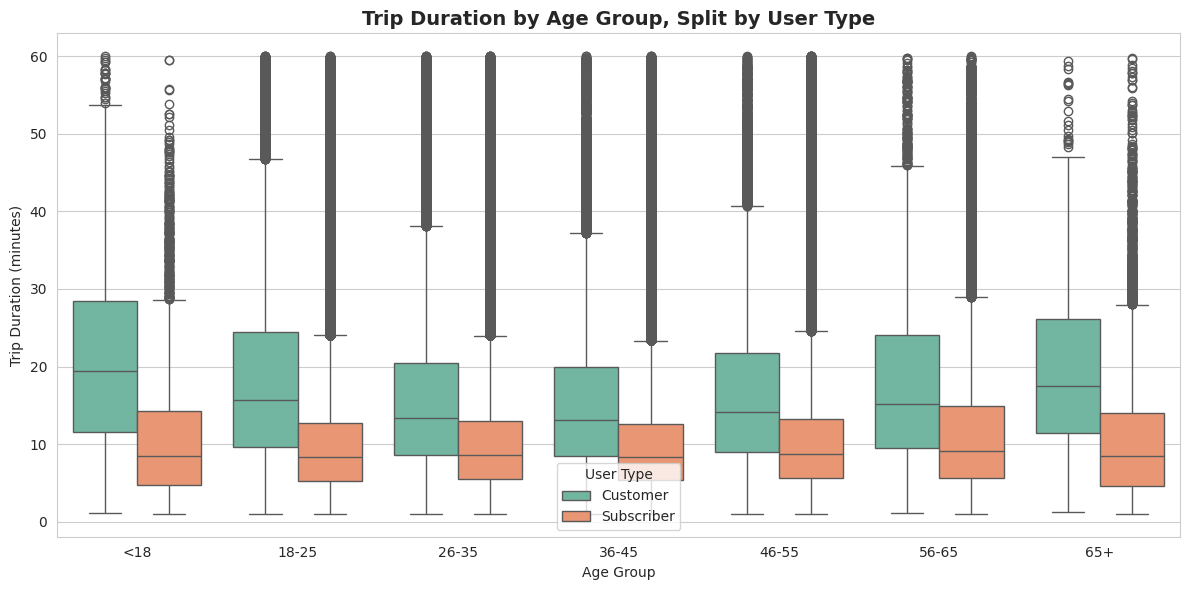

In [48]:

try:
    plot_data = df[df['trip_minutes'] <= 60]

    plt.figure(figsize=(12,6))
    sns.boxplot(data=plot_data, x='age_group', y='trip_minutes', hue='user_type', palette='Set2')
    plt.title('Trip Duration by Age Group, Split by User Type', fontsize=14, fontweight='bold')
    plt.xlabel('Age Group')
    plt.ylabel('Trip Duration (minutes)')
    plt.legend(title='User Type')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A grouped box plot combines three variables at once — age group, user type, and trip duration — showing how duration patterns differ across both demographic and membership dimensions simultaneously.

# 2. What are the insights found from the chart?
Across almost every age group, Customers consistently ride longer than Subscribers, but the gap widens noticeably in the youngest and oldest age brackets — suggesting these groups use the service more recreationally regardless of membership type.

# 3. Business impact?

Positive: Age-targeted promotions for younger/older Customers (who already ride longer, leisure-style trips) could offer duration-based bundles or day passes to increase revenue per casual ride.
Risk: Longer trips among younger/older Customers may increase exposure to late fees/lost bike incidents — proactive duration reminders for these specific segments could reduce
support costs.

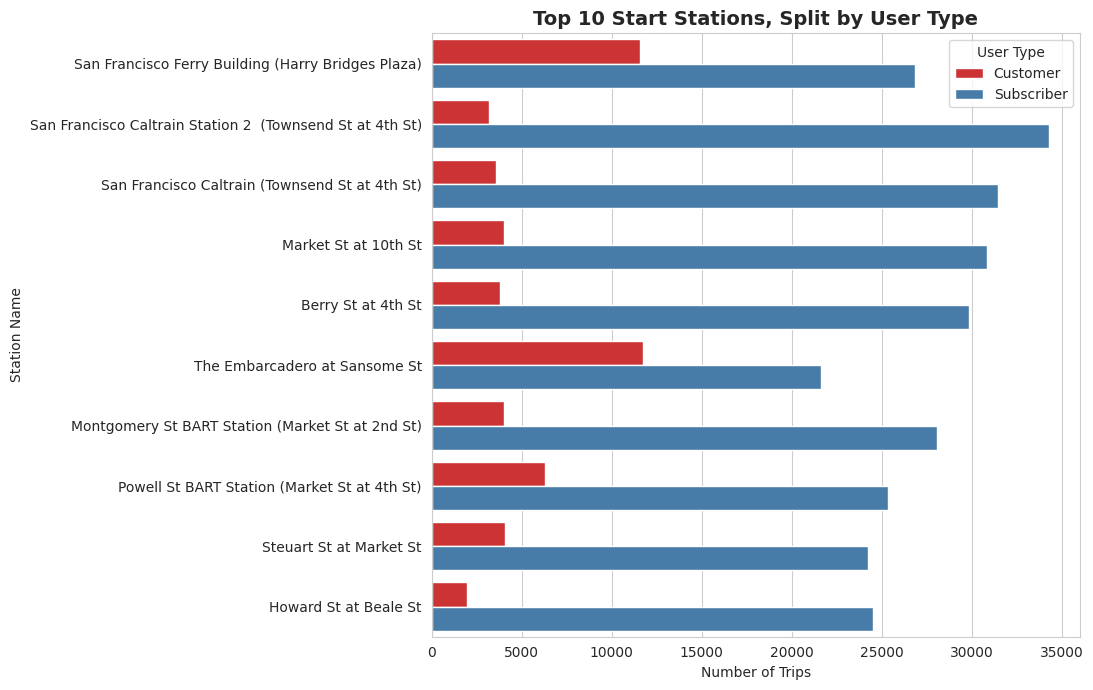

In [52]:

try:
    top10_names = df['start_station_name'].value_counts().head(10).index
    plot_data = df[df['start_station_name'].isin(top10_names)]

    plt.figure(figsize=(11,7))
    sns.countplot(data=plot_data, y='start_station_name', hue='user_type',
                  order=top10_names, palette='Set1')
    plt.title('Top 10 Start Stations, Split by User Type', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Trips')
    plt.ylabel('Station Name')
    plt.legend(title='User Type')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting chart: {e}")

# 1. Why did you pick the specific chart?

A grouped horizontal bar chart lets us see, for each top station, how much of its traffic
comes from Subscribers vs Customers — combining station popularity with user segment.
# 2. What is/are the insight(s) found from the chart?

Most top stations are overwhelmingly Subscriber-driven (consistent with transit-hub commuter
usage), but one or two of the top stations (likely tourist-adjacent, e.g., Ferry Building)
show a noticeably higher share of Customer trips compared to the others.

# 3. Business impact?

Positive: Tourist-heavy stations identified here are prime locations for Customer-focused
signage, day-pass kiosks, or partnership promotions (hotels, tour operators) to capture more
casual revenue.
Risk: Commuter-heavy stations depending almost entirely on Subscribers are vulnerable if a
major nearby employer changes commute policies (e.g., remote work shifts) — diversifying
usage at these stations could reduce that risk.

# Conclusion

This EDA on Ford GoBike's 2018 trip data (1.86M+ trips) revealed consistent usage patterns:

- The platform is commuter-driven — Subscribers dominate trips, riding short durations on
  weekdays with sharp peaks at 8-9 AM and 5-6 PM.
- Customers (casual riders) behave differently — longer trips, more weekend activity, and
  strong seasonal variation, peaking in summer.
- Riders are concentrated in the 25-40 age range and skew male, with a notable share of
  gender data missing/unspecified.
- A few transit-hub stations account for most trips, while some tourist-adjacent stations
  see higher Customer activity.
- Trip duration is best explained by user_type, not age, hour, or station location.

Overall, Ford GoBike is a mature, commuter-reliant service with an under-leveraged casual
segment. Recommendations: prioritize commute-hour fleet availability, target seasonal/
weekend riders to convert them into Subscribers, and improve signup data collection to
close the gender-data gap and reach underrepresented riders.